In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
historical_data = pd.read_csv("datasets/historical_data.csv")
historical_data.head()

,market_id,created_at,actual_delivery_time,store_id,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_dashers,total_busy_dashers,total_outstanding_orders,estimated_order_place_duration,estimated_store_to_consumer_driving_duration
0,1.0,2015-02-06 22:24:17,2015-02-06 23:27:16,1845,american,1.0,4,3441,4,557,1239,33.0,14.0,21.0,446,861.0
1,2.0,2015-02-10 21:49:25,2015-02-10 22:56:29,5477,mexican,2.0,1,1900,1,1400,1400,1.0,2.0,2.0,446,690.0
2,3.0,2015-01-22 20:39:28,2015-01-22 21:09:09,5477,NaN,1.0,1,1900,1,1900,1900,1.0,0.0,0.0,446,690.0
3,3.0,2015-02-03 21:21:45,2015-02-03 22:13:00,5477,NaN,1.0,6,6900,5,600,1800,1.0,1.0,2.0,446,289.0
4,3.0,2015-02-15 02:40:36,2015-02-15 03:20:26,5477,NaN,1.0,3,3900,3,1100,1600,6.0,6.0,9.0,446,650.0


In [4]:
historical_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 197428 entries, 0 to 197427
Data columns (total 16 columns):
 #   Column                                        Non-Null Count   Dtype  
---  ------                                        --------------   -----  
 0   market_id                                     196441 non-null  float64
 1   created_at                                    197428 non-null  object 
 2   actual_delivery_time                          197421 non-null  object 
 3   store_id                                      197428 non-null  int64  
 4   store_primary_category                        192668 non-null  object 
 5   order_protocol                                196433 non-null  float64
 6   total_items                                   197428 non-null  int64  
 7   subtotal                                      197428 non-null  int64  
 8   num_distinct_items                            197428 non-null  int64  
 9   min_item_price                                19

In [5]:
historical_data["created_at"] = pd.to_datetime(historical_data['created_at'])
historical_data["actual_delivery_time"] = pd.to_datetime(historical_data['actual_delivery_time'])

In [6]:
# feature creation
# create the target variable for regression
from datetime import datetime
historical_data["actual_total_delivery_duration"] = (historical_data["actual_delivery_time"] - historical_data["created_at"]).dt.total_seconds()/60.0

In [7]:
historical_data["busy_dashers_ratio"] = historical_data["total_busy_dashers"]/historical_data["total_onshift_dashers"]

In [8]:
# a new feature which might useful
historical_data["estimated_non_prep_duration"] = historical_data["estimated_store_to_consumer_driving_duration"] + historical_data["estimated_order_place_duration"]

In [9]:
# data preparation for modelling

In [10]:
# check ids and decide whether to encode them or not
historical_data["market_id"].nunique()

6

In [11]:
historical_data["store_id"].nunique()

6743

In [12]:
historical_data["order_protocol"].nunique()

7

In [13]:
# create dummies for order protocol
order_protocol_dummies = pd.get_dummies(historical_data.order_protocol)
order_protocol_dummies = order_protocol_dummies.add_prefix('order_protocol_dummies')
order_protocol_dummies = order_protocol_dummies.astype(int) #for True as 1 and False as 0

In [14]:
order_protocol_dummies.head()

,order_protocol_dummies1.0,order_protocol_dummies2.0,order_protocol_dummies3.0,order_protocol_dummies4.0,order_protocol_dummies5.0,order_protocol_dummies6.0,order_protocol_dummies7.0
0,1,0,0,0,0,0,0
1,0,1,0,0,0,0,0
2,1,0,0,0,0,0,0
3,1,0,0,0,0,0,0
4,1,0,0,0,0,0,0


In [15]:
# create dummy variables for market_id
market_id_dummies = pd.get_dummies(historical_data.market_id)
market_id_dummies = market_id_dummies.add_prefix('market_id_dummies')
market_id_dummies = market_id_dummies.astype(int)

In [16]:
market_id_dummies.head()

,market_id_dummies1.0,market_id_dummies2.0,market_id_dummies3.0,market_id_dummies4.0,market_id_dummies5.0,market_id_dummies6.0
0,1,0,0,0,0,0
1,0,1,0,0,0,0
2,0,0,1,0,0,0
3,0,0,1,0,0,0
4,0,0,1,0,0,0


In [17]:
# create dictionary with most repeated categories of each store to fill the null rows where it is possible
store_id_unique = historical_data["store_id"].unique().tolist()
store_id_and_category = {
    store_id: 
        historical_data[historical_data.store_id == store_id].store_primary_category.mode().iloc[0] if not historical_data[historical_data.store_id == store_id].store_primary_category.mode().empty else None
        for store_id in store_id_unique
}

In [18]:
def fill(store_id):
    """Return primary store category from the dictionary"""
    try:
        return store_id_and_category[store_id]
    except:
        return np.nan
    
# fill null values
historical_data["nan_free_store_primary_category"] = historical_data.store_id.apply(fill)

In [19]:
# create dummies for store primary category
store_primary_category_dummies = pd.get_dummies(historical_data.nan_free_store_primary_category)
store_primary_category_dummies = store_primary_category_dummies.add_prefix('category_')
store_primary_category_dummies = store_primary_category_dummies.astype(int)

In [20]:
store_primary_category_dummies.head()

,category_afghan,category_african,category_alcohol,category_alcohol-plus-food,category_american,category_argentine,category_asian,category_barbecue,category_belgian,category_brazilian,...,category_southern,category_spanish,category_steak,category_sushi,category_tapas,category_thai,category_turkish,category_vegan,category_vegetarian,category_vietnamese
0,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [21]:
# drop created_at, market_id, store_id, store_primary_category, actual_delivery_time, nan_free_store_primary_category

train_df = historical_data.drop(columns=[
    "created_at",
    "market_id",
    "store_id",
    "store_primary_category",
    "actual_delivery_time",
    "nan_free_store_primary_category"
])

train_df.head()

,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_dashers,total_busy_dashers,total_outstanding_orders,estimated_order_place_duration,estimated_store_to_consumer_driving_duration,actual_total_delivery_duration,busy_dashers_ratio,estimated_non_prep_duration
0,1.0,4,3441,4,557,1239,33.0,14.0,21.0,446,861.0,62.983333,0.424242,1307.0
1,2.0,1,1900,1,1400,1400,1.0,2.0,2.0,446,690.0,67.066667,2.000000,1136.0
2,1.0,1,1900,1,1900,1900,1.0,0.0,0.0,446,690.0,29.683333,0.000000,1136.0
3,1.0,6,6900,5,600,1800,1.0,1.0,2.0,446,289.0,51.250000,1.000000,735.0
4,1.0,3,3900,3,1100,1600,6.0,6.0,9.0,446,650.0,39.833333,1.000000,1096.0


In [22]:
train_df = pd.concat([train_df, order_protocol_dummies, market_id_dummies, store_primary_category_dummies], axis=1)

In [23]:
# align dtype over dataset
train_df = train_df.astype("float32")
train_df.head()

,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_dashers,total_busy_dashers,total_outstanding_orders,estimated_order_place_duration,...,category_southern,category_spanish,category_steak,category_sushi,category_tapas,category_thai,category_turkish,category_vegan,category_vegetarian,category_vietnamese
0,1.0,4.0,3441.0,4.0,557.0,1239.0,33.0,14.0,21.0,446.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2.0,1.0,1900.0,1.0,1400.0,1400.0,1.0,2.0,2.0,446.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.0,1.0,1900.0,1.0,1900.0,1900.0,1.0,0.0,0.0,446.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1.0,6.0,6900.0,5.0,600.0,1800.0,1.0,1.0,2.0,446.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1.0,3.0,3900.0,3.0,1100.0,1600.0,6.0,6.0,9.0,446.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [24]:
train_df.describe()

c:\Users\sayon\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\_core\_methods.py:49: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)


,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_dashers,total_busy_dashers,total_outstanding_orders,estimated_order_place_duration,...,category_southern,category_spanish,category_steak,category_sushi,category_tapas,category_thai,category_turkish,category_vegan,category_vegetarian,category_vietnamese
count,196433.000000,197428.000000,197428.000000,197428.000000,197428.000000,197428.000000,181166.000000,181166.000000,181166.000000,197428.000000,...,197428.000000,197428.000000,197428.000000,197428.000000,197428.000000,197428.000000,197428.000000,197428.000000,197428.000000,197428.000000
mean,2.882352,3.196391,2682.331543,2.670791,686.218445,1159.588623,44.808094,41.739746,58.050064,308.560181,...,0.000815,0.000187,0.005465,0.011300,0.000740,0.037254,0.001175,0.001433,0.004234,0.030928
std,1.503771,2.666546,1823.093628,1.630255,522.038635,558.411377,34.526783,32.145733,52.661831,90.139656,...,0.028545,0.013689,0.073725,0.105701,0.027184,0.189384,0.034260,0.037834,0.064935,0.173122
min,1.000000,1.000000,0.000000,1.000000,-86.000000,0.000000,-4.000000,-5.000000,-6.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,2.000000,1400.000000,1.000000,299.000000,800.000000,17.000000,15.000000,17.000000,251.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,3.000000,3.000000,2200.000000,2.000000,595.000000,1095.000000,37.000000,34.000000,41.000000,251.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,4.000000,4.000000,3395.000000,3.000000,949.000000,1395.000000,65.000000,62.000000,85.000000,446.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,7.000000,411.000000,27100.000000,20.000000,14700.000000,14700.000000,171.000000,154.000000,285.000000,2715.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [25]:
train_df["busy_dashers_ratio"].describe()

c:\Users\sayon\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\_core\_methods.py:49: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)


count    1.775900e+05
mean              NaN
std               NaN
min              -inf
25%      8.269231e-01
50%      9.622642e-01
75%      1.000000e+00
max               inf
Name: busy_dashers_ratio, dtype: float64

In [26]:
# check infinity values with using numpy isinfinite() function
train_df.replace([np.inf, -np.inf], np.nan, inplace=True)

In [27]:
train_df["busy_dashers_ratio"].describe()

count    177551.000000
mean          0.949777
std           0.406184
min         -13.000000
25%           0.826667
50%           0.962264
75%           1.000000
max          31.000000
Name: busy_dashers_ratio, dtype: float64

In [28]:
train_df["busy_dashers_ratio"] = train_df["busy_dashers_ratio"].clip(0, 1)

In [29]:
train_df["busy_dashers_ratio"].describe()

count    177551.000000
mean          0.887007
std           0.162926
min           0.000000
25%           0.826667
50%           0.962264
75%           1.000000
max           1.000000
Name: busy_dashers_ratio, dtype: float64

In [30]:
train_df.shape

(197428, 101)

In [31]:
train_df.replace([np.inf, -np.inf], np.nan, inplace=True)
train_df.dropna(inplace=True)

In [32]:
train_df.shape

(176166, 101)

In [33]:
# separate features and target variable

X = train_df.drop("actual_total_delivery_duration", axis=1)
y = train_df["actual_total_delivery_duration"]

In [34]:
X.shape

(176166, 100)

In [35]:
y.shape

(176166,)

In [36]:
# compute correlation matrix
correlation_matrix = X.corr()
correlation_matrix.head()

,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_dashers,total_busy_dashers,total_outstanding_orders,estimated_order_place_duration,...,category_southern,category_spanish,category_steak,category_sushi,category_tapas,category_thai,category_turkish,category_vegan,category_vegetarian,category_vietnamese
order_protocol,1.000000,0.003312,-0.053198,-0.028931,-0.041070,-0.087958,0.146852,0.151523,0.136114,-0.687007,...,0.000145,-0.010904,-0.027090,0.049218,-0.015855,-0.001310,-0.000069,-0.031132,0.000389,0.043129
total_items,0.003312,1.000000,0.556859,0.757858,-0.389074,-0.052938,0.033847,0.030656,0.036166,-0.021976,...,-0.003493,0.002164,-0.009625,0.054752,0.000570,0.032118,-0.000768,-0.005134,-0.005291,-0.031197
subtotal,-0.053198,0.556859,1.000000,0.682964,0.036906,0.507917,0.132234,0.126864,0.131133,0.035675,...,0.003861,0.006298,0.046944,0.067271,-0.001724,0.047646,0.001995,-0.002368,-0.004202,-0.043124
num_distinct_items,-0.028931,0.757858,0.682964,1.000000,-0.446640,0.047700,0.069302,0.063860,0.070640,0.005723,...,-0.002642,0.003108,-0.004687,0.072519,-0.000107,0.071874,0.001753,-0.004981,-0.001111,-0.038290
min_item_price,-0.041070,-0.389074,0.036906,-0.446640,1.000000,0.541311,0.040970,0.042540,0.039721,0.050982,...,0.010537,0.002724,0.041778,-0.006888,-0.001723,-0.035880,0.001816,0.004851,-0.005136,-0.012729


In [37]:
# correlation_matrix = X.corr()
# correlation_matrix.head()
# Why we do this

# Some features may contain the same information.

# Example:

# feature A = price
# feature B = price_in_cents

# These are basically identical.

# If two variables are highly correlated:

# correlation > 0.9

# they confuse some models and add unnecessary complexity.

# So we check correlations.

In [38]:
# find high correlated features

# create absolute correlation matrix
corr_matrix = correlation_matrix.abs()

# select upper triangle of correlation matrix
upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

# find features with correlation greater than o.9
to_drop = [column for column in upper_triangle.columns if any(upper_triangle[column] > 0.9)]

print("Highly correlated features:", to_drop)

Highly correlated features: ['total_busy_dashers', 'total_outstanding_orders', 'estimated_non_prep_duration', 'order_protocol_dummies1.0']


In [39]:
# Remove Highly Correlated Columns

# drop correlated features

X = X.drop(columns=to_drop)

print("Remaining features:", X.shape[1])

Remaining features: 96


In [40]:
# Train/Test Split

# split dataset
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (140932, 96)
Testing set: (35234, 96)


In [41]:
# Train First Model

# Train Linear Regression Model

from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()

# train the model
lr_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [42]:
#  What happens here

# The model tries to learn a formula like:

# delivery_time =
# a * total_items +
# b * busy_dashers_ratio +
# c * estimated_non_prep_duration

# It learns coefficients a, b, c from the data.

In [43]:
# Make predictions on the test set

# predict delivery times

y_pred = lr_model.predict(X_test)

In [44]:
# Evaluate the model

from sklearn.metrics import mean_squared_error, mean_absolute_error

# compute error
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print("Linear Regression RMSE:", rmse)
print("Linear Regression MAE:", mae)

Linear Regression RMSE: 18.02812371349016
Linear Regression MAE: 12.695955276489258


In [45]:
# What these metrics mean

# MAE

# average prediction error

# Example:

# MAE = 7 minutes

# means predictions are on average 7 minutes off.

# RMSE

# Penalizes large errors more strongly.

# Lower values = better model.

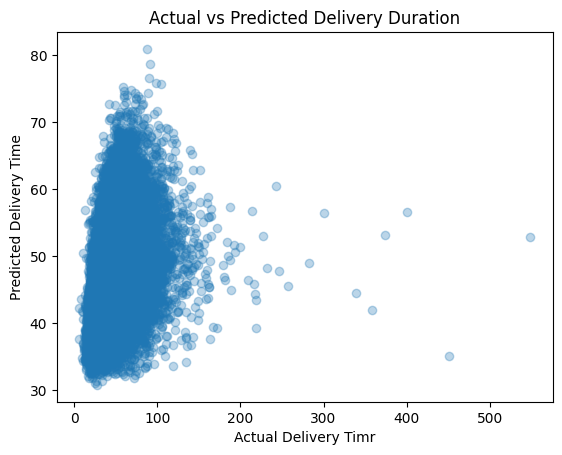

In [46]:
# Visualise Predictions

plt.scatter(y_test, y_pred, alpha=0.3)
plt.xlabel("Actual Delivery Timr")
plt.ylabel("Predicted Delivery Time")
plt.title("Actual vs Predicted Delivery Duration")
plt.show()

In [47]:
# Model Evaluation Insight – Actual vs Predicted Delivery Duration

# Observation from the scatter plot:

# The plot compares actual delivery duration (x-axis) with predicted delivery duration (y-axis).

# If the model were perfect, all points would lie along a diagonal line (y = x).

# What we observe instead:

# Most predictions fall between ~30 to 60 minutes, even when actual delivery times vary much more.

# The model struggles to predict very large delivery durations (e.g., 200–500 minutes).

# There are several outliers in the actual delivery time, which the model fails to capture.

# Predictions appear compressed into a narrow band, indicating the model is predicting near the average delivery time.

# Interpretation:

# This behavior suggests underfitting.

# The current model (Linear Regression):

# assumes a linear relationship between features and delivery duration

# cannot capture complex or nonlinear relationships in the data

# Examples of nonlinear factors in real delivery systems:

# traffic fluctuations

# restaurant preparation delays

# driver availability spikes

# order volume surges

# These factors are difficult for a simple linear model to capture.

# Conclusion:

# The Linear Regression model serves as a baseline model, but its predictive performance is limited.

# Next Step:

# To better capture nonlinear relationships in the data, we will train more powerful models such as:

# Random Forest Regressor

# Gradient Boosting models

# These models can learn more complex patterns and are expected to produce more accurate predictions.

In [48]:
# Train Random Forest Regressor

from sklearn.ensemble import RandomForestRegressor

# initialize the model
rf_model = RandomForestRegressor(
    n_estimators=100,   # number of trees
    max_depth=20,       # limit tree depth, trees learn general patterns
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,    #(ensures reproducibility)
    n_jobs=-1           #(this telss sklearn, use all cpu cores. training becomes much faster)
)

In [49]:
# Train the model

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [50]:
# make predictions
rf_predictions = rf_model.predict(X_test)

In [51]:
# evaluate the model

from random import Random

from sklearn.metrics import mean_squared_error, mean_absolute_error

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))
rf_mae = mean_absolute_error(y_test, rf_predictions)

print("Random Forest RMSE:", rf_rmse)
print("Random Forest MAE:", rf_mae)

Random Forest RMSE: 17.410726575696103
Random Forest MAE: 12.060540060376894


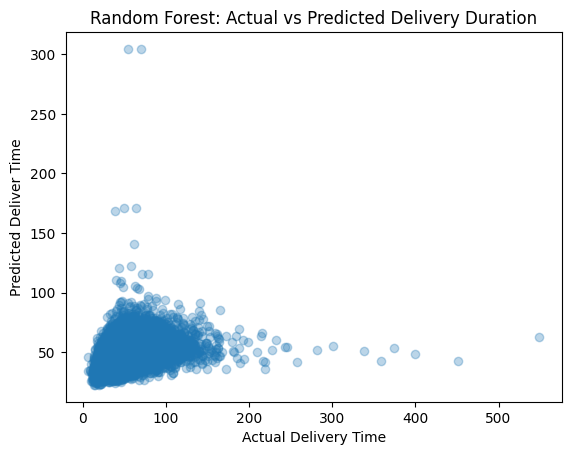

In [52]:
plt.scatter(y_test, rf_predictions, alpha=0.3)

plt.xlabel("Actual Delivery Time")
plt.ylabel("Predicted Deliver Time")
plt.title("Random Forest: Actual vs Predicted Delivery Duration")

plt.show()

In [53]:
# Train XGBoost Regressor

from xgboost import XGBRegressor

In [54]:
# initialize the model

xgb_model = XGBRegressor(
    n_estimators = 400,     # number of trees
    learning_rate = 0.05,   # how fast the model learns, slower learning but usually better performance
    max_depth = 6,         # limit tree depth, trees learn general patterns
    subsample = 0.8,    # use 80% of data for each tree, helps prevent overfitting\
    colsample_bytree = 0.8, # use 80% of features for each tree, helps prevent overfitting
    random_state = 42,
    n_jobs = -1
)

In [55]:
# Train the model

xgb_model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None
,feature_types,None


In [56]:
# The model now learns relationships between:

# order size
# restaurant type
# marketplace demand
# driver availability
# estimated durations

In [57]:
# make predictions

xgb_predictions = xgb_model.predict(X_test)

In [58]:
# Evaluate the model

xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_predictions))
xgb_mae = mean_absolute_error(y_test, xgb_predictions)

print("XGBoost RMSE:", xgb_rmse)
print("XGBoost MAE:", xgb_mae)

XGBoost RMSE: 17.169979528860377
XGBoost MAE: 11.757647514343262


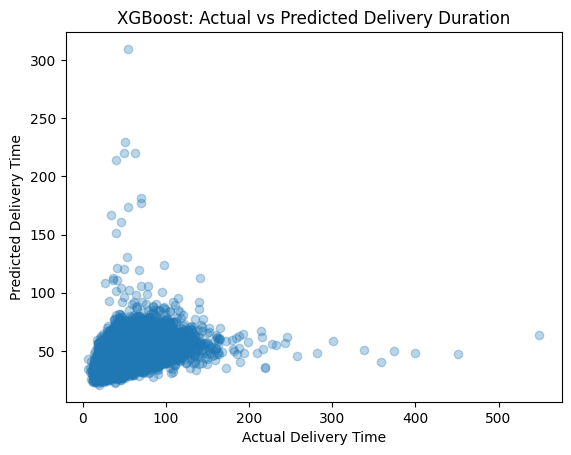

In [59]:
plt.scatter(y_test, xgb_predictions, alpha=0.3)

plt.xlabel("Actual Delivery Time")
plt.ylabel("Predicted Delivery Time")
plt.title("XGBoost: Actual vs Predicted Delivery Duration")

plt.show()

In [60]:
# Train LightGBM Regressor

from lightgbm import LGBMRegressor

In [61]:
# Initialize the model

lgb_model = LGBMRegressor(
    n_estimators = 400,
    learning_rate = 0.05,
    max_depth = 6,
    subsample = 0.8,
    colsample_bytree = 0.8,
    random_state = 42,
    n_jobs = -1
)

In [62]:
# train the model
lgb_model.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000979 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1691
[LightGBM] [Info] Number of data points in the train set: 140932, number of used features: 84
[LightGBM] [Info] Start training from score 47.582347
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gai

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,6
,learning_rate,0.05
,n_estimators,400
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [63]:
# make predictions

lgb_predictions = lgb_model.predict(X_test)

In [64]:
# evaluate the model

lgb_rmse = np.sqrt(mean_squared_error(y_test, lgb_predictions))
lgb_mae = mean_absolute_error(y_test, lgb_predictions)

print("LightGBM RMSE:", lgb_rmse)
print("LightGBM MAE:", lgb_mae)

LightGBM RMSE: 17.114835166255084
LightGBM MAE: 11.80405173976539


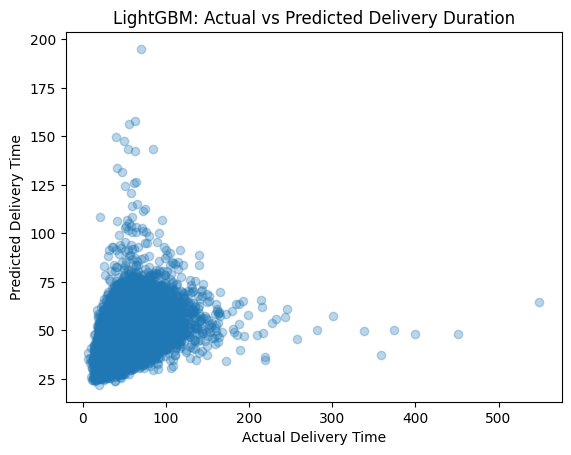

In [65]:
plt.scatter(y_test, lgb_predictions, alpha=0.3)

plt.xlabel("Actual Delivery Time")
plt.ylabel("Predicted Delivery Time")
plt.title("LightGBM: Actual vs Predicted Delivery Duration")

plt.show()

In [66]:
# Hyperparameter Tuning

# So far we trained models using manually selected parameters.  
# While these parameters already provide good performance, we can often improve the model by systematically searching for better hyperparameters.

# Hyperparameters control how a model learns patterns from the data.

# Examples include:
# - number of trees
# - tree depth
# - learning rate
# - subsampling ratios

# To perform this search efficiently, we use **RandomizedSearchCV**, which tests multiple random combinations of parameters using cross-validation.

# This helps find a configuration that improves generalization without manually testing every possible parameter combination.

In [67]:
# Import RandomizedSearchCV

from sklearn.model_selection import RandomizedSearchCV

In [68]:
# What this cell does

# RandomizedSearchCV automatically tries different combinations of hyperparameters and evaluates them using cross-validation.

# Instead of manually testing models, it:

# samples parameter combinations

# trains the model

# evaluates performance

# selects the best configuration

In [69]:
xgb_param_dist = {
    "n_estimators": [200, 300, 400, 500],
    "max_depth": [4, 5, 6, 7],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "subsample": [0.7, 0.8, 0.9],
    "colsample_bytree": [0.7, 0.8, 0.9],
    "min_child_weight": [1, 3, 5]
}




# This defines the search space for hyperparameters.

# Instead of fixing one value, we allow the search algorithm to try multiple possibilities.

# Example:

# max_depth = [4,5,6,7]

# means the model will test trees of different depths to see which generalizes best.

In [70]:
# base xgb model

xgb_base = XGBRegressor(
    random_state = 42,
    n_jobs = -1
)

In [71]:
# This defines the search space for hyperparameters.

# Instead of fixing one value, we allow the search algorithm to try multiple possibilities.

# Example:

# max_depth = [4,5,6,7]

# means the model will test trees of different depths to see which generalizes best.

In [72]:
# Run RandomizedSearchCV for XGBoost

xgb_random_search = RandomizedSearchCV(
    estimator = xgb_base,
    param_distributions = xgb_param_dist,
    n_iter = 20,  # number of random combinations to try
    cv = 3,  # number of cross-validation folds
    scoring = "neg_mean_squared_error",  # use RMSE as the evaluation metric
    verbose = 1,  # print progress
    random_state = 42,
    n_jobs = -1
)

xgb_random_search.fit(X_train, y_train)

Fitting 3 folds for each of 20 candidates, totalling 60 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBRegressor(...state=42, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.7, 0.8, ...], 'learning_rate': [0.01, 0.03, ...], 'max_depth': [4, 5, ...], 'min_child_weight': [1, 3, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies

In [73]:
print("Best XGBoost Parameters:", xgb_random_search.best_params_)

Best XGBoost Parameters: {'subsample': 0.9, 'n_estimators': 300, 'min_child_weight': 3, 'max_depth': 7, 'learning_rate': 0.05, 'colsample_bytree': 0.7}


In [74]:
best_xgb = xgb_random_search.best_estimator_

xgb_tuned_predictions = best_xgb.predict(X_test)

xgb_tuned_rmse = np.sqrt(mean_squared_error(y_test, xgb_tuned_predictions))
xgb_tuned_mae = mean_absolute_error(y_test, xgb_tuned_predictions)

print("Tuned XGBoost RMSE:", xgb_tuned_rmse)
print("Tuned XGBoost MAE:", xgb_tuned_mae)

Tuned XGBoost RMSE: 17.195395026210416
Tuned XGBoost MAE: 11.777973175048828


In [75]:
# lightgbm parameter space

lgb_param_dist = {
    "n_estimators": [200, 300, 400, 500],
    "max_depth": [4, 5, 6, 7],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "subsample": [0.7, 0.8, 0.9],
    "colsample_bytree": [0.7, 0.8, 0.9],
    "num_leaves": [20, 31, 40]
}

In [ ]:
# What this cell does

# Defines hyperparameters for LightGBM.

# LightGBM has a parameter called:

# num_leaves

# which controls how complex the tree structure becomes.

In [76]:
# base lbgm model

lgb_base = LGBMRegressor(
    random_state=42,
    n_jobs=-1
)

In [77]:
# RandomizedSearchCV for LightGBM

lgb_random_search = RandomizedSearchCV(
    estimator=lgb_base,
    param_distributions=lgb_param_dist,
    n_iter=20,
    scoring="neg_mean_squared_error",
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

lgb_random_search.fit(X_train, y_train)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004964 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1691
[LightGBM] [Info] Number of data points in the train set: 140932, number of used features: 84
[LightGBM] [Info] Start training from score 47.582347
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: 

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LGBMRegressor...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.7, 0.8, ...], 'learning_rate': [0.01, 0.03, ...], 'max_depth': [4, 5, ...], 'n_estimators': [200, 300, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies t

In [78]:
print("Best LightGBM Parameters:", lgb_random_search.best_params_)

Best LightGBM Parameters: {'subsample': 0.8, 'num_leaves': 20, 'n_estimators': 300, 'max_depth': 4, 'learning_rate': 0.05, 'colsample_bytree': 0.7}


In [79]:
best_lgb = lgb_random_search.best_estimator_

lgb_tuned_predictions = best_lgb.predict(X_test)

lgb_tuned_rmse = np.sqrt(mean_squared_error(y_test, lgb_tuned_predictions))
lgb_tuned_mae = mean_absolute_error(y_test, lgb_tuned_predictions)

print("Tuned LightGBM RMSE:", lgb_tuned_rmse)
print("Tuned LightGBM MAE:", lgb_tuned_mae)

Tuned LightGBM RMSE: 17.094860378325354
Tuned LightGBM MAE: 11.861003457042559


In [80]:
# model comparison

model_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "XGBoost",
        "LightGBM",
        "Tuned XGBoost",
        "Tuned LightGBM"
    ],
    "RMSE": [
        rmse,
        rf_rmse,
        xgb_rmse,
        lgb_rmse,
        xgb_tuned_rmse,
        lgb_tuned_rmse
    ],
    "MAE": [
        mae,
        rf_mae,
        xgb_mae,
        lgb_mae,
        xgb_tuned_mae,
        lgb_tuned_mae
    ]
})

model_results

,Model,RMSE,MAE
0,Linear Regression,18.028124,12.695955
1,Random Forest,17.410727,12.060540
2,XGBoost,17.169980,11.757648
3,LightGBM,17.114835,11.804052
4,Tuned XGBoost,17.195395,11.777973
5,Tuned LightGBM,17.094860,11.861003


In [ ]:
# Model Comparison Summary

# Several machine learning models were trained to predict delivery duration.

# Performance improved as models became more capable of capturing nonlinear relationships in the data.

# Key observations:

# - Linear Regression underperformed because it assumes linear relationships.
# - Random Forest improved performance by modeling nonlinear interactions.
# - Gradient boosting models (XGBoost and LightGBM) produced the best results.
# - Hyperparameter tuning slightly improved LightGBM performance.

# The final tuned LightGBM model achieved the best RMSE of approximately **17.09 minutes**.

# This indicates that, on average, predictions are about **17 minutes away from the true delivery duration**, which is reasonable given the complexity and noise present in real-world delivery systems.

In [98]:
# create a dataframe to compare actual vs predicted values

results_df = pd.DataFrame({
    "Actual_Delivery_Time" : y_test,
    "Predicted_Delivery_Time_before_tuning" : lgb_predictions,
    "Predicted_Delivery_Time_after_tuning" : lgb_tuned_predictions
})

results_df.head(10)

,Actual_Delivery_Time,Predicted_Delivery_Time_before_tuning,Predicted_Delivery_Time_after_tuning
103339,46.250000,51.416497,51.825382
2300,44.683334,50.434135,49.451156
100879,29.033333,30.417111,31.343147
120098,40.049999,44.892590,46.051298
156655,37.950001,38.043133,37.660309
19079,21.616667,32.636879,32.722983
14114,38.349998,39.133932,40.305250
180734,51.083332,53.742302,56.448379
61781,32.150002,46.203927,47.594576
150561,45.266666,41.918648,41.110726


In [124]:
results_df[["Error_before_tuning", "Error_after_tuning"]].head(10)

,Error_before_tuning,Error_after_tuning
103339,5.166497,5.575382
2300,5.750800,4.767822
100879,1.383778,2.309814
120098,4.842591,6.001299
156655,0.093133,0.289692
19079,11.020212,11.106316
14114,0.783934,1.955252
180734,2.658970,5.365047
61781,14.053925,15.444574
150561,3.348019,4.155940


In [ ]:
# Hyperparameter tuning produced only marginal improvement.
# The manually configured LightGBM model already performed near optimal for this dataset.

In [123]:
results_df["Better_Model"] = np.where(
    results_df["Error_after_tuning"] < results_df["Error_before_tuning"],
    "After Tuning",
    "Before Tuning"
)

results_df[["Error_before_tuning", "Error_after_tuning", "Better_Model"]].head(10)

,Error_before_tuning,Error_after_tuning,Better_Model
103339,5.166497,5.575382,Before Tuning
2300,5.750800,4.767822,After Tuning
100879,1.383778,2.309814,Before Tuning
120098,4.842591,6.001299,Before Tuning
156655,0.093133,0.289692,Before Tuning
19079,11.020212,11.106316,Before Tuning
14114,0.783934,1.955252,Before Tuning
180734,2.658970,5.365047,Before Tuning
61781,14.053925,15.444574,Before Tuning
150561,3.348019,4.155940,Before Tuning


In [119]:
# Convert prediction to a real ETA timestamp

# example: assume order placed now
import datetime

order_time = datetime.datetime.now()

predicted_minutes = lgb_predictions[0]

eta = order_time + datetime.timedelta(minutes=float(predicted_minutes))

print("Order placed at:", order_time)
print("Estimated delivery time:", eta)

Order placed at: 2026-03-07 16:16:39.743208
Estimated delivery time: 2026-03-07 17:08:04.733036


In [120]:
# Convert prediction to a real ETA timestamp

# example: assume order placed now
import datetime

order_time = datetime.datetime.now()

predicted_minutes = lgb_tuned_predictions[0]

eta = order_time + datetime.timedelta(minutes=float(predicted_minutes))

print("Order placed at:", order_time)
print("Estimated delivery time:", eta)

Order placed at: 2026-03-07 16:16:42.360741
Estimated delivery time: 2026-03-07 17:08:31.883660


In [107]:
(results_df["Better_Model"] == "After Tuning").sum()

np.int64(16436)

In [108]:
(results_df["Better_Model"] == "Before Tuning").sum()

np.int64(18798)

In [ ]:
# Original model wins on number of predictions
# Tuned model wins on large errors

In [128]:
# Extract feature importance from the tuned LightGBM model

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_lgb.feature_importances_
})

# sort features by importance
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
6,total_onshift_dashers,751
8,estimated_store_to_consumer_driving_duration,375
2,subtotal,365
9,busy_dashers_ratio,358
5,max_item_price,316
4,min_item_price,206
7,estimated_order_place_duration,155
0,order_protocol,139
16,market_id_dummies1.0,130
3,num_distinct_items,121


In [ ]:
# Feature Importance Insights

# The LightGBM model identified several operational and marketplace variables as key drivers of delivery duration.

# The most influential feature was the number of available dashers (`total_onshift_dashers`), indicating that driver supply strongly affects delivery speed.

# Estimated driving duration between the store and the customer was also highly important, confirming that geographic distance plays a major role in delivery time.

# Order-related features such as subtotal and item prices contributed to predictions, suggesting that larger or more complex orders require longer preparation times.

# Marketplace congestion variables, such as the ratio of busy dashers, also influenced delivery duration. This indicates that supply-demand imbalance in the delivery network can lead to delays.

# Overall, the model captures the core components of the food delivery pipeline: order preparation, driver availability, and travel time.

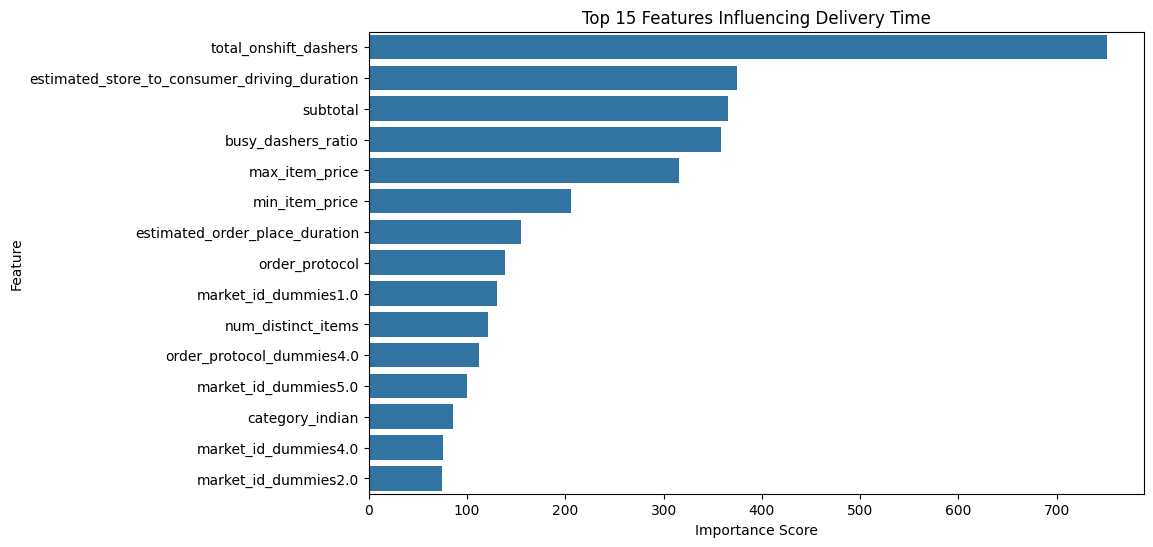

In [129]:
# plot top 15 most important features

plt.figure(figsize=(10,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_importance.head(15)
)

plt.title("Top 15 Features Influencing Delivery Time")
plt.xlabel("Importance Score")
plt.ylabel("Feature")

plt.show()

In [ ]:
# this is a strong result

# Your model discovered exactly the factors we expect in real delivery systems:

# Driver availability
# Distance
# Order complexity
# Marketplace congestion
# Restaurant systems
# Location

# That means the model is learning meaningful real-world patterns, not random noise.

In [130]:
feature_importance.head(25)

,Feature,Importance
6,total_onshift_dashers,751
8,estimated_store_to_consumer_driving_duration,375
2,subtotal,365
9,busy_dashers_ratio,358
5,max_item_price,316
4,min_item_price,206
7,estimated_order_place_duration,155
0,order_protocol,139
16,market_id_dummies1.0,130
3,num_distinct_items,121


In [ ]:
# implemented a full end-to-end machine learning pipeline exactly like a real industry workflow:

# Data ingestion

# Feature engineering

# Data cleaning

# Encoding

# Multicollinearity removal

# Baseline model

# Tree-based models

# Gradient boosting models

# Hyperparameter tuning

# Model comparison

# Prediction analysis

# ETA simulation

# Feature importance analysis

# Visualization

# Business insights